In [1]:
## 1. Import Libraries and Set Reproducibility

import os
import random
import zipfile

import numpy as np
import pandas as pd

# Fixed random seed
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Random seed set to:", RANDOM_SEED)

Random seed set to: 42


In [2]:
## 2. Mount Google Drive and Load Final Manifests

from google.colab import drive
drive.mount("/content/drive")

PROJECT_ROOT = "/content/drive/MyDrive/Master_datascience_thesis"

preprocessing_dir = os.path.join(PROJECT_ROOT, "outputs", "preprocessing")

model_output_dir = os.path.join(PROJECT_ROOT, "outputs", "traditional_ml")

os.makedirs(model_output_dir, exist_ok=True)

train_df = pd.read_csv(os.path.join(preprocessing_dir, "final_train_metadata.csv"))

validation_df = pd.read_csv(os.path.join(preprocessing_dir, "final_validation_metadata.csv"))

print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Model output folder ready:", os.path.exists(model_output_dir))

Mounted at /content/drive
Training images: 6480
Validation images: 1794
Model output folder ready: True


In [3]:
## 3. Set Image Location and Resize Size

zip_path = os.path.join(PROJECT_ROOT,"data","TBX11K.zip")

# Fixed image size for all four models
IMAGE_SIZE = (224, 224)

print("TBX11K ZIP found:", os.path.exists(zip_path))
print("Image resize size:", IMAGE_SIZE)

TBX11K ZIP found: True
Image resize size: (224, 224)


Sample path: sick/s0230.png
Image shape: (224, 224)


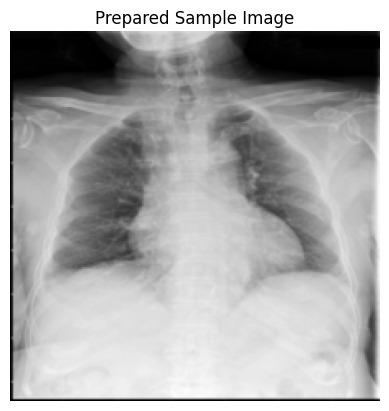

In [4]:
## 4. Load and Prepare One Image

from PIL import Image
import matplotlib.pyplot as plt

# Convert one image to grayscale and resize it to 224 × 224
def load_image(zip_file, image_path):
    full_path = "TBX11K/imgs/" + image_path

    with zip_file.open(full_path) as file:
        image = Image.open(file).convert("L")
        image = image.resize(IMAGE_SIZE, Image.Resampling.BILINEAR)

    return np.array(image)


# Test with one training image
with zipfile.ZipFile(zip_path, "r") as zip_file:
    sample_path = train_df.iloc[0]["path"]
    sample_image = load_image(zip_file, sample_path)

print("Sample path:", sample_path)
print("Image shape:", sample_image.shape)

plt.imshow(sample_image, cmap="gray")
plt.title("Prepared Sample Image")
plt.axis("off")
plt.show()

In [5]:
## 5. Set HOG Parameters and Test One Image

from skimage.feature import hog

# Fixed HOG settings
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

# Extract HOG features from the sample image
sample_hog = hog(
    sample_image,
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
    block_norm="L2-Hys",
    feature_vector=True
)

print("Number of HOG features:", len(sample_hog))

Number of HOG features: 6084


In [6]:
## 6. Extract or Load HOG Features

from tqdm.auto import tqdm

train_hog_path = os.path.join(model_output_dir, "training_hog_features.npy")

validation_hog_path = os.path.join( model_output_dir, "validation_hog_features.npy")

def extract_hog_features(dataframe):

    features = np.empty( (len(dataframe), len(sample_hog)), dtype=np.float32)

    with zipfile.ZipFile(zip_path, "r") as zip_file:

        for index, image_path in enumerate( tqdm(dataframe["path"], total=len(dataframe))):

            image = load_image(zip_file, image_path)

            features[index] = hog(
                image,
                orientations=HOG_ORIENTATIONS,
                pixels_per_cell=HOG_PIXELS_PER_CELL,
                cells_per_block=HOG_CELLS_PER_BLOCK,
                block_norm="L2-Hys",
                feature_vector=True
            )

    return features


# Load saved features when available
if (os.path.exists(train_hog_path) and os.path.exists(validation_hog_path)):

    X_train = np.load(train_hog_path, allow_pickle=False)

    X_validation = np.load( validation_hog_path, allow_pickle=False)

    print("Saved HOG features loaded")

else:

    X_train = extract_hog_features(train_df)
    X_validation = extract_hog_features(validation_df)

    np.save(train_hog_path, X_train)
    np.save(validation_hog_path, X_validation)

    print("HOG features extracted and saved")


y_train = train_df["label"].to_numpy()
y_validation = validation_df["label"].to_numpy()

print("Training features:", X_train.shape)
print("Validation features:", X_validation.shape)
print("Training labels:", y_train.shape)
print("Validation labels:", y_validation.shape)

  0%|          | 0/6480 [00:00<?, ?it/s]

  0%|          | 0/1794 [00:00<?, ?it/s]

HOG features extracted and saved
Training features: (6480, 6084)
Validation features: (1794, 6084)
Training labels: (6480,)
Validation labels: (1794,)


In [7]:
## 7. Set Up Stratified Cross-Validation

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

print("Stratified 5-fold cross-validation ready")

Stratified 5-fold cross-validation ready


In [8]:
## 8. Create the SVM Pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipeline = Pipeline([("scaler", StandardScaler()),("svm", SVC(class_weight="balanced"))])

print("SVM pipeline ready")

SVM pipeline ready


In [9]:
## 9. Set Up SVM Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# Logarithmically spaced values for SVM regularisation
svm_parameters = {"svm__C": [0.1, 1, 10, 100], "svm__kernel": ["linear", "rbf"]}

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_parameters,
    scoring="roc_auc",
    cv=cv,
    refit=True,
    n_jobs=2,
    verbose=2
)

print("SVM hyperparameter search ready")

SVM hyperparameter search ready


In [10]:
## 10. Run SVM Hyperparameter Tuning

svm_search.fit(X_train, y_train)

print("Best SVM parameters:", svm_search.best_params_)
print("Best cross-validation AUROC:", round(svm_search.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best SVM parameters: {'svm__C': 10, 'svm__kernel': 'rbf'}
Best cross-validation AUROC: 0.984


In [11]:
## 11. Evaluate Best SVM on Validation Data

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Best fitted SVM pipeline
best_svm = svm_search.best_estimator_

# Validation predictions
y_pred_svm = best_svm.predict(X_validation)
y_score_svm = best_svm.decision_function(X_validation)

# Confusion matrix values
tn, fp, fn, tp = confusion_matrix(y_validation,y_pred_svm).ravel()

# Calculate metrics
accuracy = accuracy_score(y_validation, y_pred_svm)
precision = precision_score(y_validation, y_pred_svm)
sensitivity = recall_score(y_validation, y_pred_svm)
specificity = tn / (tn + fp)
f1 = f1_score(y_validation, y_pred_svm)
auroc = roc_auc_score(y_validation, y_score_svm)

print("SVM Validation Results")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Sensitivity:", round(sensitivity, 4))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(f1, 4))
print("AUROC:", round(auroc, 4))

print("\nConfusion Matrix Values")
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

SVM Validation Results
Accuracy: 0.9654
Precision: 0.9792
Sensitivity: 0.705
Specificity: 0.9981
F1-score: 0.8198
AUROC: 0.9884

Confusion Matrix Values
True Negatives: 1591
False Positives: 3
False Negatives: 59
True Positives: 141


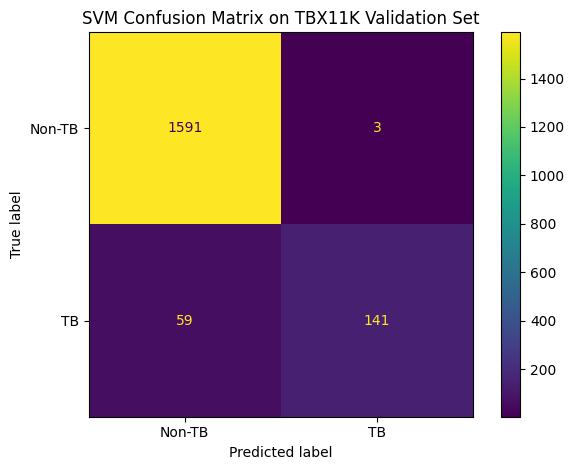

In [12]:
## 12. Plot SVM Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_validation, y_pred_svm, display_labels=["Non-TB", "TB"], values_format="d")

plt.title("SVM Confusion Matrix on TBX11K Validation Set")
plt.tight_layout()

plt.savefig( os.path.join( model_output_dir, "svm_confusion_matrix.png" ), dpi=300, bbox_inches="tight")

plt.show()

In [13]:
## 13. Save SVM Validation Results

svm_results = pd.DataFrame({
    "Model": ["SVM"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Sensitivity": [sensitivity],
    "Specificity": [specificity],
    "F1_score": [f1],
    "AUROC": [auroc],
    "TN": [tn],
    "FP": [fp],
    "FN": [fn],
    "TP": [tp]
})

display(svm_results)

svm_results.to_csv(
    os.path.join(model_output_dir, "svm_validation_results.csv"),
    index=False
)

print("SVM results saved")

,Model,Accuracy,Precision,Sensitivity,Specificity,F1_score,AUROC,TN,FP,FN,TP
0,SVM,0.96544,0.979167,0.705,0.998118,0.819767,0.988363,1591,3,59,141


SVM results saved


In [14]:
## 14. Save the Trained SVM Model

import joblib

svm_model_path = os.path.join(model_output_dir,"best_svm_hog_model.pkl")

joblib.dump(best_svm, svm_model_path)

print("SVM model saved:", os.path.exists(svm_model_path))

SVM model saved: True


In [15]:
## 15. Set Up Random Forest Hyperparameter Tuning

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Random Forest model
rf_model = RandomForestClassifier( class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)

# Hyperparameter grid
rf_parameters = { "n_estimators": [200, 400, 800], "max_depth": [None, 20]}

rf_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_parameters,
    scoring="roc_auc",
    cv=cv,
    refit=True,
    n_jobs=1,
    verbose=2
)

print("Random Forest hyperparameter search ready")

Random Forest hyperparameter search ready


In [16]:
## 16. Run Random Forest Hyperparameter Tuning

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:", rf_search.best_params_)
print("Best cross-validation AUROC:", round(rf_search.best_score_, 4))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ...................max_depth=None, n_estimators=200; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=200; total time= 1.3min
[CV] END ...................max_depth=None, n_estimators=200; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=200; total time= 1.3min
[CV] END ...................max_depth=None, n_estimators=200; total time= 1.4min
[CV] END ...................max_depth=None, n_estimators=400; total time= 2.8min
[CV] END ...................max_depth=None, n_estimators=400; total time= 2.7min
[CV] END ...................max_depth=None, n_estimators=400; total time= 2.8min
[CV] END ...................max_depth=None, n_estimators=400; total time= 2.7min
[CV] END ...................max_depth=None, n_estimators=400; total time= 2.8min
[CV] END ...................max_depth=None, n_estimators=800; total time= 5.5min
[CV] END ...................max_depth=None, n_est

In [17]:
## 17. Evaluate Random Forest on Validation Data

# Best fitted Random Forest
best_rf = rf_search.best_estimator_

# Validation predictions
y_pred_rf = best_rf.predict(X_validation)
y_score_rf = best_rf.predict_proba(X_validation)[:, 1]

# Confusion matrix values
rf_tn, rf_fp, rf_fn, rf_tp = confusion_matrix(y_validation, y_pred_rf).ravel()

# Calculate metrics
rf_accuracy = accuracy_score(y_validation, y_pred_rf)
rf_precision = precision_score(y_validation, y_pred_rf, zero_division=0)
rf_sensitivity = recall_score(y_validation, y_pred_rf)
rf_specificity = rf_tn / (rf_tn + rf_fp)
rf_f1 = f1_score(y_validation, y_pred_rf)
rf_auroc = roc_auc_score(y_validation, y_score_rf)

print("Random Forest Validation Results")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Sensitivity:", round(rf_sensitivity, 4))
print("Specificity:", round(rf_specificity, 4))
print("F1-score:", round(rf_f1, 4))
print("AUROC:", round(rf_auroc, 4))

print("\nConfusion Matrix Values")
print("True Negatives:", rf_tn)
print("False Positives:", rf_fp)
print("False Negatives:", rf_fn)
print("True Positives:", rf_tp)

Random Forest Validation Results
Accuracy: 0.9153
Precision: 1.0
Sensitivity: 0.24
Specificity: 1.0
F1-score: 0.3871
AUROC: 0.9719

Confusion Matrix Values
True Negatives: 1594
False Positives: 0
False Negatives: 152
True Positives: 48


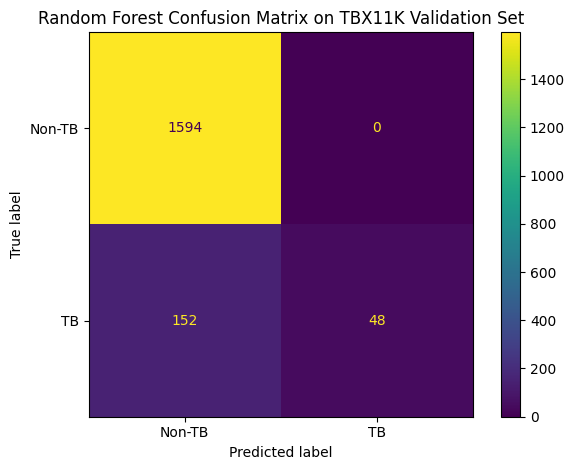

In [18]:
## 18. Plot Random Forest Confusion Matrix

ConfusionMatrixDisplay.from_predictions( y_validation, y_pred_rf, display_labels=["Non-TB", "TB"], values_format="d")

plt.title("Random Forest Confusion Matrix on TBX11K Validation Set")
plt.tight_layout()

plt.savefig( os.path.join( model_output_dir, "random_forest_confusion_matrix.png" ), dpi=300, bbox_inches="tight")

plt.show()

In [19]:
## 19. Save Random Forest Validation Results

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [rf_accuracy],
    "Precision": [rf_precision],
    "Sensitivity": [rf_sensitivity],
    "Specificity": [rf_specificity],
    "F1_score": [rf_f1],
    "AUROC": [rf_auroc],
    "TN": [rf_tn],
    "FP": [rf_fp],
    "FN": [rf_fn],
    "TP": [rf_tp]
})

rf_results.to_csv(
    os.path.join(model_output_dir, "random_forest_validation_results.csv"),
    index=False
)

display(rf_results)
print("Random Forest results saved")

,Model,Accuracy,Precision,Sensitivity,Specificity,F1_score,AUROC,TN,FP,FN,TP
0,Random Forest,0.915273,1.0,0.24,1.0,0.387097,0.971948,1594,0,152,48


Random Forest results saved


In [20]:
## 20. Save the Trained Random Forest Model

rf_model_path = os.path.join( model_output_dir, "best_random_forest_hog_model.pkl")

joblib.dump(best_rf, rf_model_path)

print("Random Forest model saved:", os.path.exists(rf_model_path))

Random Forest model saved: True


In [21]:
## 21. Compare SVM and Random Forest Results

traditional_ml_results = pd.concat([svm_results, rf_results],ignore_index=True)

traditional_ml_results.to_csv(os.path.join(model_output_dir, "traditional_ml_validation_results.csv"),index=False)

display(traditional_ml_results)

print("Traditional ML comparison saved")

,Model,Accuracy,Precision,Sensitivity,Specificity,F1_score,AUROC,TN,FP,FN,TP
0,SVM,0.965440,0.979167,0.705,0.998118,0.819767,0.988363,1591,3,59,141
1,Random Forest,0.915273,1.000000,0.240,1.000000,0.387097,0.971948,1594,0,152,48


Traditional ML comparison saved


In [22]:
## 22. Save Traditional ML Validation Scores

score_df = validation_df[ ["path", "label"]].reset_index(drop=True).copy()

score_df["SVM_score"] = y_score_svm
score_df["Random_Forest_score"] = y_score_rf

score_df.to_csv( os.path.join( model_output_dir, "traditional_ml_validation_scores.csv"), index=False)

print("Traditional ML validation scores saved")
print("Rows saved:", len(score_df))

Traditional ML validation scores saved
Rows saved: 1794
